## Galaxy10 DECals – Galaxy morphology classification

Baseline CNN vs EfficientNetB0 transfer learning (frozen and fine-tuned).
Produces:
- EDA figures
- Training curves
- Confusion matrices
- Misclassified examples
- Model comparison table
- Training histories


In [2]:
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import utils, layers, models, backend as K
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# EfficientNet and ResNet Backbones
from tensorflow.keras.applications import EfficientNetB0, EfficientNetB3, ResNet50
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_pre
from tensorflow.keras.applications.resnet50 import preprocess_input as res_pre
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_pre


from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score,
)
from astroNN.datasets.galaxy10 import galaxy10cls_lookup

import warnings
warnings.filterwarnings('ignore')

In [2]:
#  Configuration 
NUM_CLASSES = 10
BATCH_SIZE = 64
EPOCHS_BASELINE = 30
EPOCHS_TL = 30
EPOCHS_FT = 30
RANDOM_STATE = 42

plt.rcParams["figure.dpi"] = 120

np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

|### Data Loading and Exploratory Data Analysis

In [3]:
# 10 types of galaxies
NUM_CLASSES = 10

with h5py.File('Galaxy10_DECals.h5', 'r') as F:
    images = np.array(F['images'])
    labels = np.array(F['ans'])

print("Raw images shape:", images.shape)


labels_oh = utils.to_categorical(labels, NUM_CLASSES).astype(np.float32)
images = images.astype(np.float32)

class_names = [galaxy10cls_lookup(i) for i in range(NUM_CLASSES)]

# print class names
for i in range(NUM_CLASSES):
    print(i, ":", galaxy10cls_lookup(i))

Raw images shape: (17736, 256, 256, 3)
0 : Disturbed
1 : Merging
2 : Round Smooth
3 : Smooth, Cigar shaped
4 : Cigar Shaped Smooth
5 : Barred Spiral
6 : Unbarred Tight Spiral
7 : Unbarred Loose Spiral
8 : Edge-on without Bulge
9 : Edge-on with Bulge


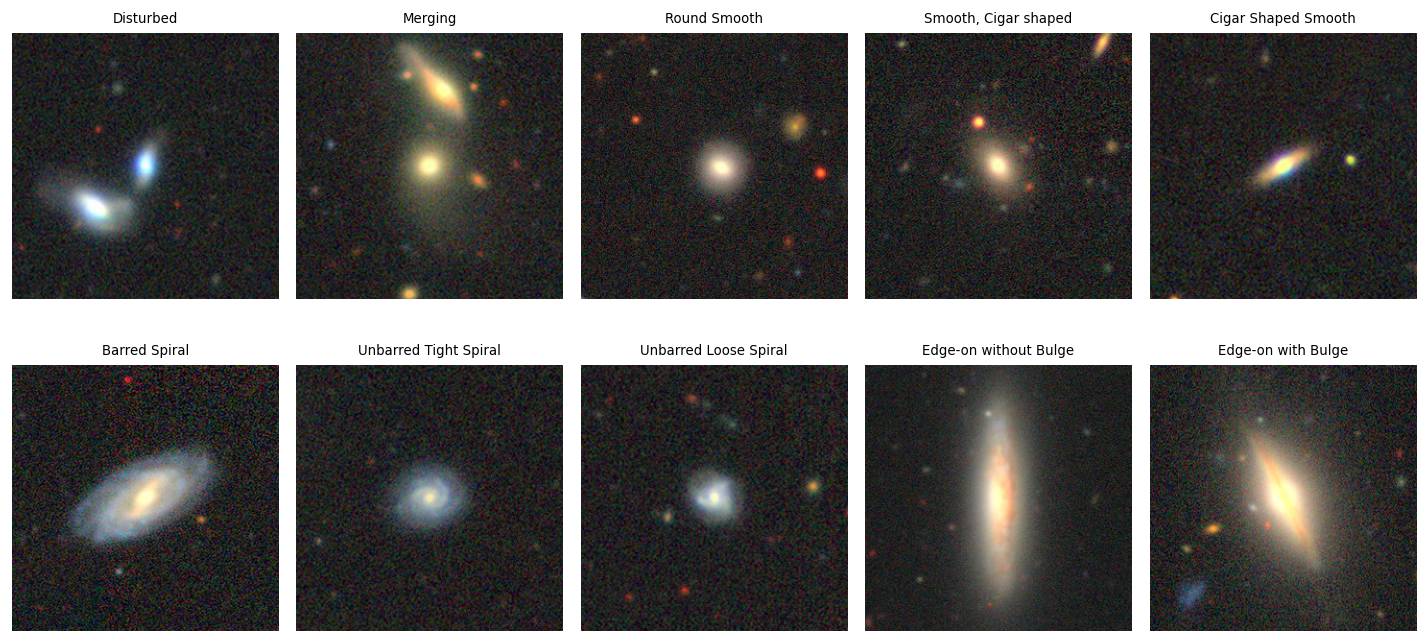

In [4]:
y_idx = labels

rand_idx = [np.random.choice(np.where(y_idx == i)[0]) for i in range(NUM_CLASSES)]

# plot example of each class
plt.figure(figsize=(12, 6))
for j, idx in enumerate(rand_idx):
    ax = plt.subplot(2, 5, j + 1)
    ax.imshow(images[idx].astype(np.float32) / 255.0 )
    ax.set_title(galaxy10cls_lookup(y_idx[idx]), fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()

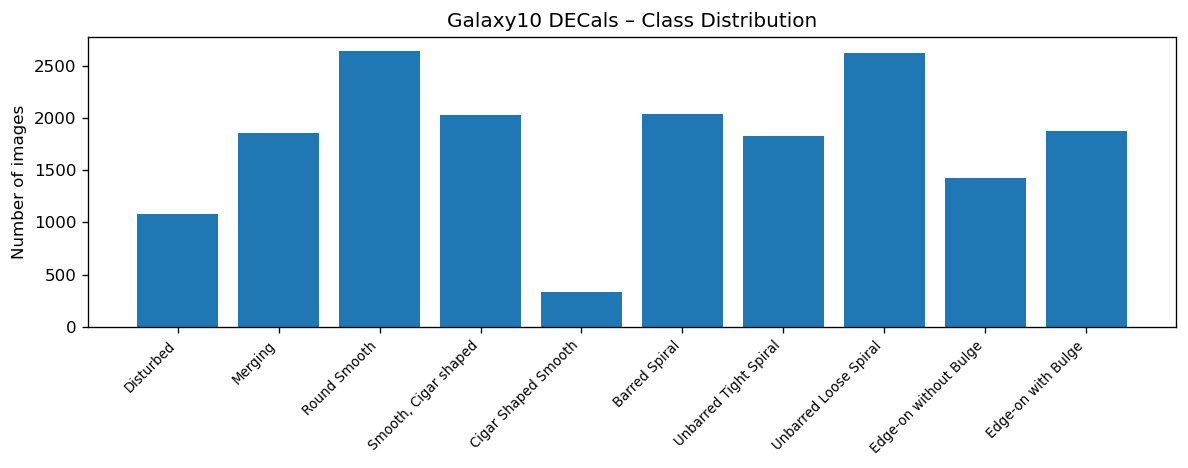

0 Disturbed: 1081
1 Merging: 1853
2 Round Smooth: 2645
3 Smooth, Cigar shaped: 2027
4 Cigar Shaped Smooth: 334
5 Barred Spiral: 2043
6 Unbarred Tight Spiral: 1829
7 Unbarred Loose Spiral: 2628
8 Edge-on without Bulge: 1423
9 Edge-on with Bulge: 1873


In [5]:
# Class distribution before splitting
classes, counts = np.unique(labels, return_counts=True)
class_names = [galaxy10cls_lookup(c) for c in classes]

plt.figure(figsize=(10, 4))
plt.bar(classes, counts)
plt.xticks(classes, class_names, rotation=45, ha="right", fontsize=8)
plt.ylabel("Number of images")
plt.title("Galaxy10 DECals – Class Distribution")
plt.tight_layout()
plt.show()

for c, cnt in zip(classes, counts):
    print(f"{c} {galaxy10cls_lookup(c)}: {cnt}")

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split

train_idx, test_idx = train_test_split(np.arange(labels.shape[0]), test_size=0.1)
train_images, train_labels, test_images, test_labels = images[train_idx], labels[train_idx], images[test_idx], labels[test_idx]

### Pre-Processing

In [ ]:

import tensorflow as tf
import numpy as np
import h5py
from sklearn.model_selection import train_test_split

# ============================================================
# Config
# ============================================================
BATCH = 16
IMG_SIZE = 224
EPOCHS = 10
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ============================================================
# Load H5 File
# ============================================================
with h5py.File("Galaxy10_DECals.h5", "r") as F:
    images = np.array(F["images"])
    labels = np.array(F["ans"])

images = images.astype("float32") / 255.0

# ============================================================
# Train/Val/Test Split
# ============================================================
X_train, X_temp, y_train, y_temp = train_test_split(
    images, labels, test_size=0.3, stratify=labels, random_state=SEED
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=SEED
)

# ============================================================
# TF Dataset Wrappers
# ============================================================
AUTOTUNE = tf.data.experimental.AUTOTUNE

def preprocess_train(img, label):
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_rotation(img, 0.1)

    return img, label

def preprocess_test(img, label):
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    return img, label

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)) \
    .shuffle(5000) \
    .map(preprocess_train, num_parallel_calls=AUTOTUNE) \
    .batch(BATCH) \
    .prefetch(AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val)) \
    .map(preprocess_test, num_parallel_calls=AUTOTUNE) \
    .batch(BATCH) \
    .prefetch(AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)) \
    .map(preprocess_test, num_parallel_calls=AUTOTUNE) \
    .batch(BATCH) \
    .prefetch(AUTOTUNE)

# ============================================================
# EfficientNetV2-S
# ============================================================
base = tf.keras.applications.EfficientNetV2S(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    pooling="avg"
)

x = tf.keras.layers.Dense(256, activation="relu")(base.output)
x = tf.keras.layers.Dropout(0.4)(x)
output = tf.keras.layers.Dense(10, activation="softmax")(x)

model = tf.keras.Model(inputs=base.input, outputs=output)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# ============================================================
# Manual Early Stopping (match PyTorch version)
# ============================================================
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = None
        self.counter = 0
        self.stop = False

    def step(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
            return

        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1

        if self.counter >= self.patience:
            self.stop = True

early_stop = EarlyStopping(patience=5, min_delta=0.0005)
best_weights = None
best_val_loss = float("inf")

# ============================================================
# Training Loop
# ============================================================
for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    train_hist = model.fit(train_ds, epochs=1, verbose=1)
    val_hist = model.evaluate(val_ds, verbose=1)

    val_loss = val_hist[0]
    val_acc = val_hist[1]

    print(f"train_loss={train_hist.history['loss'][0]:.4f}, val_loss={val_loss:.4f}, val_acc={val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_weights = model.get_weights()

    early_stop.step(val_loss)
    if early_stop.stop:
        print(f"Early stopping triggered at epoch {epoch+1}")
        break

# restore best model
if best_weights is not None:
    model.set_weights(best_weights)

# ============================================================
# Test Evaluation
# ============================================================
test_loss, test_acc = model.evaluate(test_ds)
print("Final Test Accuracy:", test_acc)


: 

EfficientNet-specific normalization for transfer learning.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from tqdm import tqdm
import numpy as np
import h5py

# ============================================================
# Config
# ============================================================
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH = 64
IMG_SIZE = 224
EPOCHS = 30
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

class EarlyStopping:
    def __init__(self, patience=5, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = None
        self.counter = 0
        self.should_stop = False

    def step(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
            return

        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1

        if self.counter >= self.patience:
            self.should_stop = True

class EarlyStopping:
    def __init__(self, patience=5, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = None
        self.counter = 0
        self.should_stop = False

    def step(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
            return

        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1

        if self.counter >= self.patience:
            self.should_stop = True


# ============================================================
# Custom Dataset
# ============================================================
class GalaxyDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]
        label = self.labels[idx]

        img = img.astype(np.float32) / 255.0

        if self.transform:
            img = self.transform(img)

        return img, int(label)

# ============================================================
# Load H5 file
# ============================================================
with h5py.File("Galaxy10_DECals.h5", "r") as F:
    images = np.array(F["images"])
    labels = np.array(F["ans"])

# ============================================================
# Train/val/test splits
# ============================================================
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    images, labels, test_size=0.30, stratify=labels, random_state=SEED
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED
)

# ============================================================
# Transforms
# ============================================================
train_tf = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8,1.0)),
    transforms.ToTensor(),
])

test_tf = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

# ============================================================
# Datasets
# ============================================================
train_ds = GalaxyDataset(X_train, y_train, transform=train_tf)
val_ds   = GalaxyDataset(X_val, y_val, transform=test_tf)
test_ds  = GalaxyDataset(X_test, y_test, transform=test_tf)

# ============================================================
# Dataloaders (YOUR FIX APPLIED HERE)
# num_workers = 0 → avoid macOS spawn crash
# ============================================================
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False, num_workers=0)

# ============================================================
# EfficientNetV2-S
# ============================================================
from torchvision.models import efficientnet_v2_s, EfficientNet_V2_S_Weights

weights = EfficientNet_V2_S_Weights.IMAGENET1K_V1
model = efficientnet_v2_s(weights=weights)

# Replace classifier head
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 10)

model = model.to(DEVICE)

# ============================================================
# Optimizer & Loss
# ============================================================
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

# ============================================================
# Training Loop
# ============================================================
def train_one_epoch(epoch):
    model.train()
    total = 0
    correct = 0
    running_loss = 0.0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]")

    for imgs, labels in pbar:
        imgs = imgs.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()
        out = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        preds = out.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += imgs.size(0)

        pbar.set_postfix(loss=running_loss/total, acc=correct/total)

    return running_loss/total, correct/total


def validate(epoch):
    model.eval()
    total = 0
    correct = 0
    running_loss = 0.0

    pbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Val]")

    with torch.no_grad():
        for imgs, labels in pbar:
            imgs = imgs.to(DEVICE)
            labels = labels.to(DEVICE)

            out = model(imgs)
            loss = criterion(out, labels)

            running_loss += loss.item() * imgs.size(0)
            preds = out.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += imgs.size(0)

            pbar.set_postfix(loss=running_loss/total, acc=correct/total)

    return running_loss/total, correct/total

# ============================================================
# Run Training
# ============================================================
early_stop = EarlyStopping(patience=5, min_delta=0.0005)

best_val_loss = float("inf")
best_state = None

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(epoch)
    val_loss, val_acc = validate(epoch)

    print(f"Epoch {epoch+1}: train_acc={train_acc:.4f} val_acc={val_acc:.4f}")

    # Save best weights
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = model.state_dict()

    # Early stopping check
    early_stop.step(val_loss)
    if early_stop.should_stop:
        print(f"Early stopping triggered at epoch {epoch+1}")
        break

# Load best weights
if best_state is not None:
    model.load_state_dict(best_state)


# ============================================================
# Test Evaluation
# ============================================================
model.eval()
total = 0
correct = 0

with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc="Testing"):
        imgs = imgs.to(DEVICE)
        labels = labels.to(DEVICE)

        out = model(imgs)
        preds = out.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += imgs.size(0)

print("Final Test Accuracy:", correct/total)


Epoch 1/30 [Train]:   1%|          | 1/194 [00:54<2:56:04, 54.74s/it, acc=0.125, loss=2.32]

In [ ]:
# ============================================================
# 9. Full Evaluation on Test Set (Accuracy, Precision, Recall, F1, Confusion Matrix)
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import numpy as np

# Galaxy10 class names
class_names = [
    "Disturbed", "Merging", "Round Smooth", "In-between Smooth",
    "Cigar Shaped Smooth", "Barred Spiral", "Unbarred Spiral",
    "Edge-on w/ Bulge", "Edge-on no Bulge", "Other"
]


def evaluate_tf(model, dataset):
    all_preds = []
    all_labels = []

    for batch_imgs, batch_labels in dataset:
        preds = model(batch_imgs, training=False)
        preds = tf.argmax(preds, axis=1).numpy()

        all_preds.extend(preds)
        all_labels.extend(batch_labels.numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    # ------------------------------
    # Metrics
    # ------------------------------
    acc = accuracy_score(all_labels, all_preds)

    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    print("\n===== Test Metrics =====")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")

    # ------------------------------
    # Confusion Matrix
    # ------------------------------
    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(10, 8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap="Blues", xticks_rotation="vertical", colorbar=False)
    plt.title("Confusion Matrix — Galaxy10 Classification")
    plt.tight_layout()
    plt.show()

    return acc, precision, recall, f1


# Run final evaluation
acc, precision, recall, f1 = evaluate_tf(model, test_ds)
print("Final Test Accuracy:", acc)

# Save model
model.save("galaxy_classifier_tf.h5")
print("Model saved as galaxy_classifier_tf.h5")


In [ ]:
# ============================================================
# 9. Full Evaluation on Test Set (Accuracy, Precision, Recall, F1, Confusion Matrix)
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Optional: names for Galaxy10 classes
class_names = [
    "Disturbed", "Merging", "Round Smooth", "In-between Smooth",
    "Cigar Shaped Smooth", "Barred Spiral", "Unbarred Spiral",
    "Edge-on w/ Bulge", "Edge-on no Bulge", "Other"
]


def evaluate(model, loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc="Testing"):
            imgs = imgs.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(imgs)
            preds = outputs.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # ------------------------------
    # Metrics
    # ------------------------------
    acc = accuracy_score(all_labels, all_preds)

    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    print("\n===== Test Metrics =====")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")

    # ------------------------------
    # Confusion Matrix
    # ------------------------------
    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(10, 8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap="Blues", xticks_rotation="vertical", colorbar=False)
    plt.title("Confusion Matrix — Galaxy10 Classification")
    plt.tight_layout()
    plt.show()

    return acc, precision, recall, f1


# Run final evaluation
acc, precision, recall, f1 = evaluate(model, test_loader)

# Save model
torch.save(model.state_dict(), "galaxy_classifier.pth")
print("Model saved as galaxy_classifier.pth")


#### Transfer learning with EfficientNet

###  Fine-turned Efficientnetb0 model

### Validation and Performance Metrics

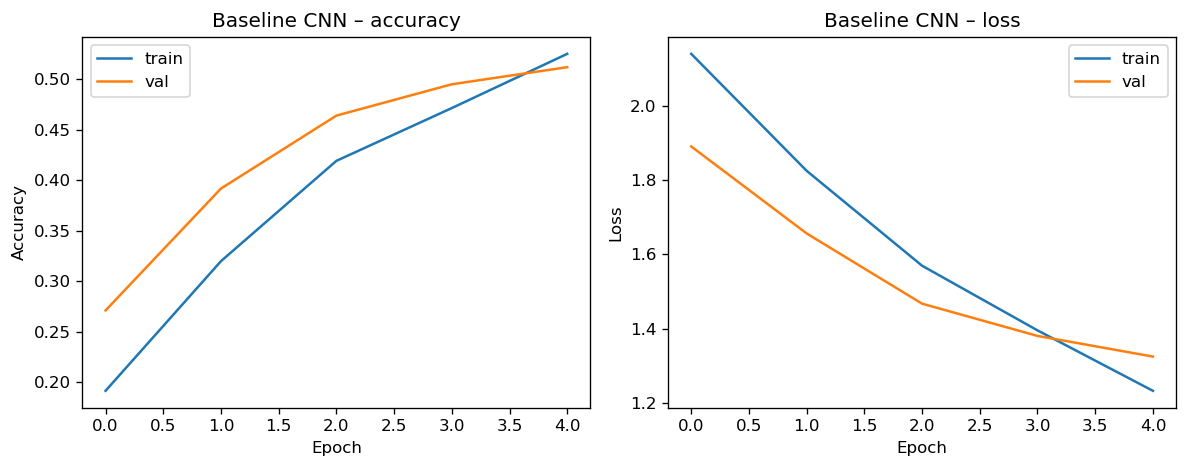

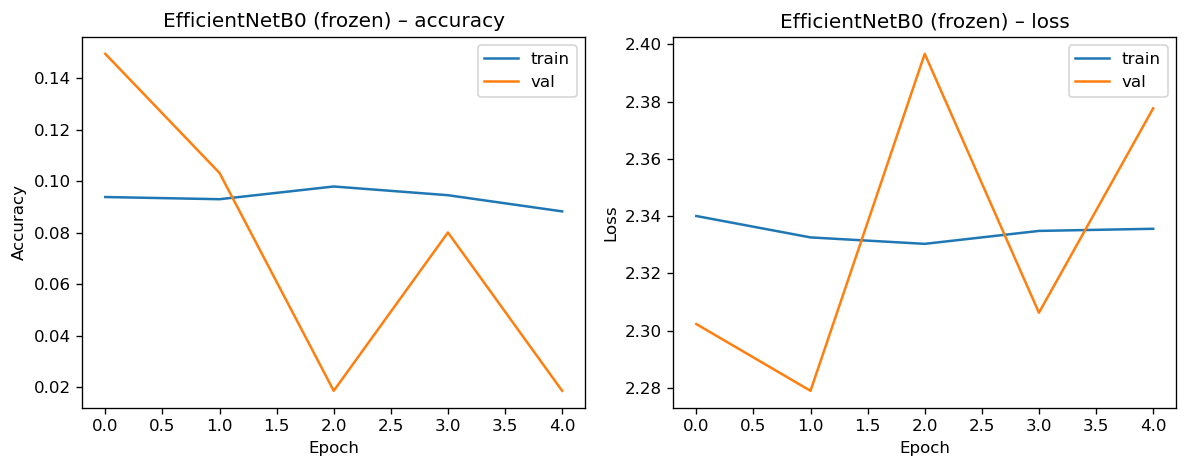

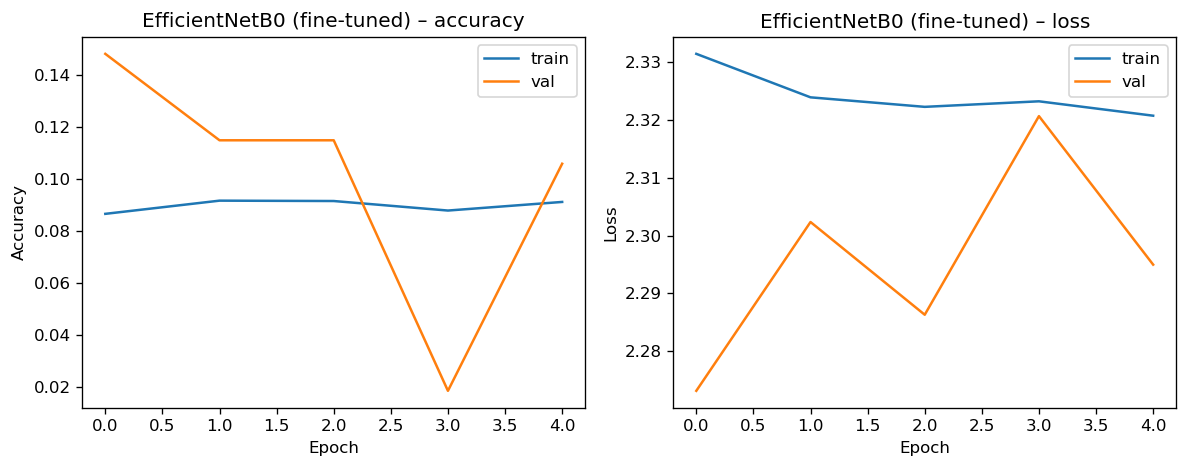

In [ ]:
#  Training curves 
def plot_history(history, title: str, filename: str | None = None) -> None:
    """Plot accuracy and loss curves for one model."""
    plt.figure(figsize=(10, 4))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history["accuracy"], label="train")
    plt.plot(history.history["val_accuracy"], label="val")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.title(f"{title} – accuracy")

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history["loss"], label="train")
    plt.plot(history.history["val_loss"], label="val")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.title(f"{title} – loss")

    plt.tight_layout()
    if filename is not None:
        plt.savefig(filename, bbox_inches="tight")
    plt.show()


plot_history(history_baseline, "Baseline CNN", "curve_baseline_cnn.png")
plot_history(history_tl, "EfficientNetB0 (frozen)", "curve_efficientnet_frozen.png")
plot_history(history_ft, "EfficientNetB0 (fine-tuned)", "curve_efficientnet_ft.png")

In [ ]:
def evaluate_model(
    model: tf.keras.Model,
    X: np.ndarray,
    y_true_int: np.ndarray,
    model_name: str,
    class_names_local: list[str],
    filename_prefix: str,
) -> dict:
    """Evaluate model on a set and plot confusion matrix."""
    y_prob = model.predict(X, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)

    report = classification_report(
        y_true_int,
        y_pred,
        target_names=class_names_local,
        output_dict=True,
        digits=3,
    )

    cm = confusion_matrix(y_true_int, y_pred)

    acc = report["accuracy"]
    macro_f1 = report["macro avg"]["f1-score"]
    macro_recall = report["macro avg"]["recall"]

    print(f"\n=== {model_name} ===")
    print(f"Accuracy: {acc:.4f}")
    print(f"Macro F1: {macro_f1:.4f}")
    print(f"Macro Recall: {macro_recall:.4f}")
    print(
        classification_report(
            y_true_int,
            y_pred,
            target_names=class_names_local,
            digits=3,
        )
    )

    fig, ax = plt.subplots(figsize=(8, 8))
    disp = ConfusionMatrixDisplay(cm, display_labels=class_names_local)
    disp.plot(ax=ax, xticks_rotation=90, colorbar=False)
    plt.title(f"{model_name} – Confusion matrix (test set)")
    plt.tight_layout()
    cm_filename = f"{filename_prefix}_confusion_matrix.png"
    plt.savefig(cm_filename, bbox_inches="tight")
    plt.show()

    return {
        "model": model_name,
        "accuracy": acc,
        "macro_f1": macro_f1,
        "macro_recall": macro_recall,
    }

In [ ]:
baseline_eval_model = tf.keras.models.load_model("baseline_cnn.h5")
frozen_eval_model = tf.keras.models.load_model("efficientnetb0_frozen.keras")
finetuned_eval_model = tf.keras.models.load_model("efficientnetb0_finetuned.h5")


=== Baseline CNN ===
Accuracy: 0.5293
Macro F1: 0.5141
Macro Recall: 0.5364
                       precision    recall  f1-score   support

            Disturbed      0.372     0.296     0.330       108
              Merging      0.553     0.454     0.499       185
         Round Smooth      0.605     0.621     0.613       264
 Smooth, Cigar shaped      0.488     0.502     0.495       203
  Cigar Shaped Smooth      0.324     0.647     0.431        34
        Barred Spiral      0.504     0.341     0.407       205
Unbarred Tight Spiral      0.439     0.590     0.503       183
Unbarred Loose Spiral      0.467     0.407     0.435       263
Edge-on without Bulge      0.756     0.697     0.725       142
   Edge-on with Bulge      0.621     0.807     0.702       187

             accuracy                          0.529      1774
            macro avg      0.513     0.536     0.514      1774
         weighted avg      0.531     0.529     0.524      1774



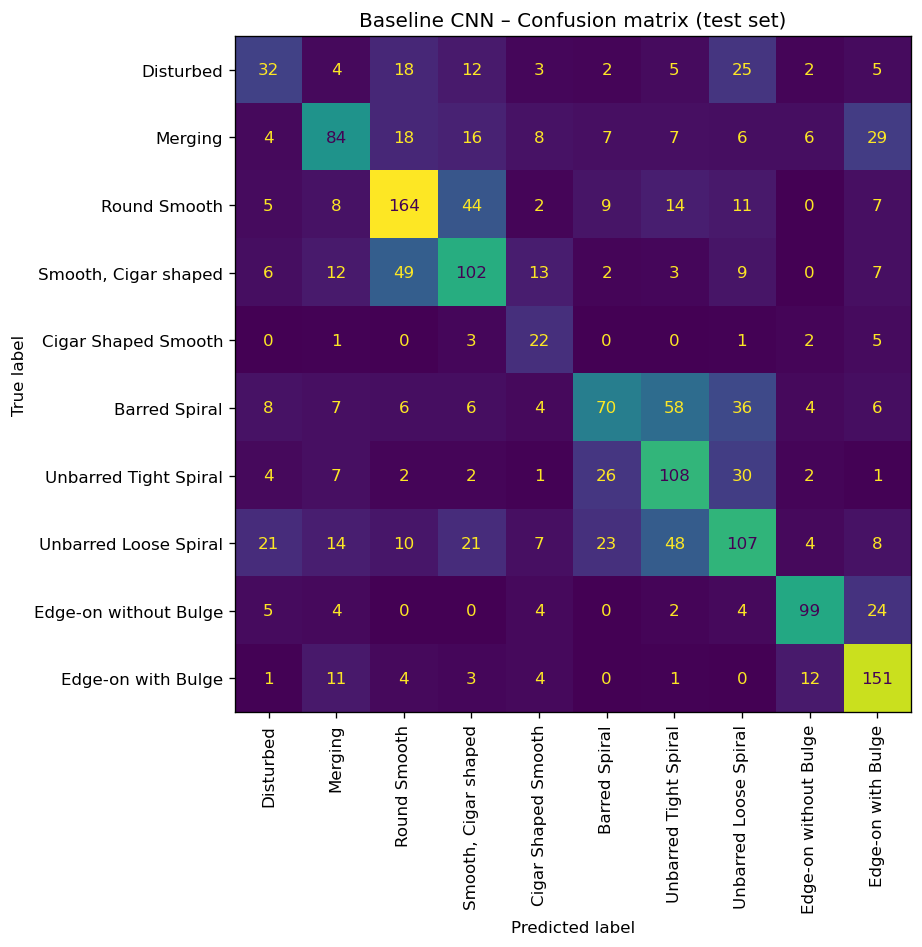


=== EfficientNetB0 (Frozen TL) ===
Accuracy: 0.1032
Macro F1: 0.0187
Macro Recall: 0.1000
                       precision    recall  f1-score   support

            Disturbed      0.000     0.000     0.000       108
              Merging      0.000     0.000     0.000       185
         Round Smooth      0.000     0.000     0.000       264
 Smooth, Cigar shaped      0.000     0.000     0.000       203
  Cigar Shaped Smooth      0.000     0.000     0.000        34
        Barred Spiral      0.000     0.000     0.000       205
Unbarred Tight Spiral      0.103     1.000     0.187       183
Unbarred Loose Spiral      0.000     0.000     0.000       263
Edge-on without Bulge      0.000     0.000     0.000       142
   Edge-on with Bulge      0.000     0.000     0.000       187

             accuracy                          0.103      1774
            macro avg      0.010     0.100     0.019      1774
         weighted avg      0.011     0.103     0.019      1774



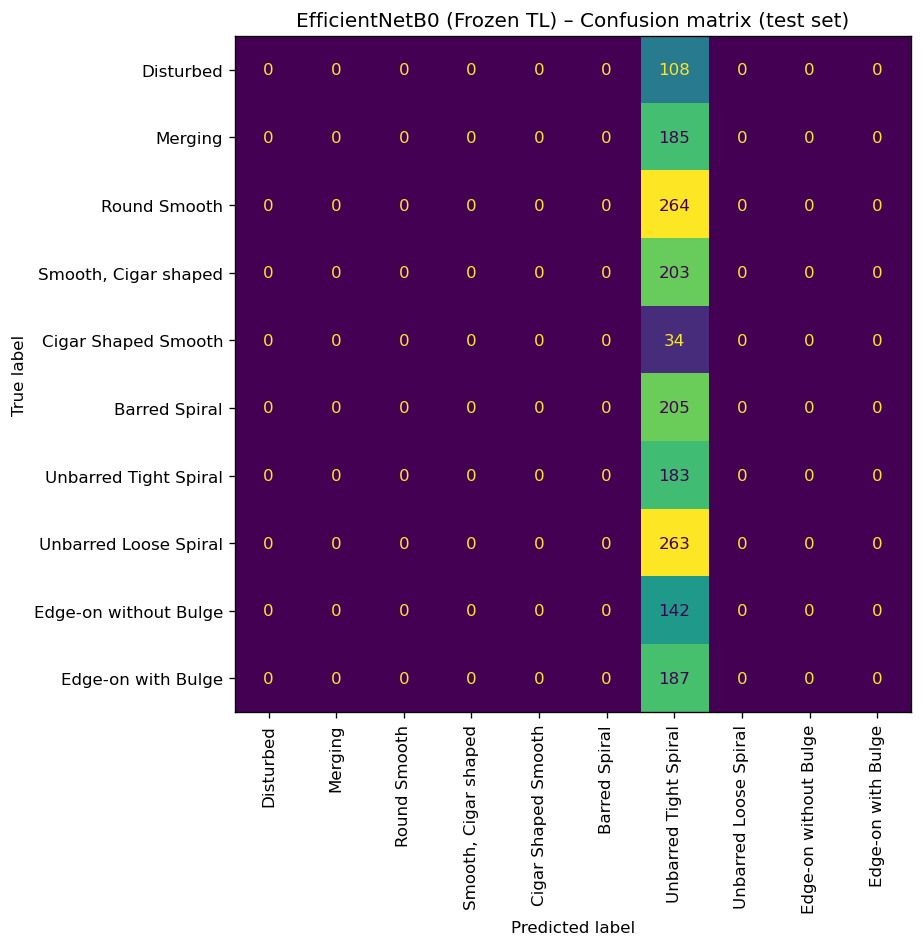


=== EfficientNetB0 (Fine-Tuned) ===
Accuracy: 0.1144
Macro F1: 0.0205
Macro Recall: 0.1000
                       precision    recall  f1-score   support

            Disturbed      0.000     0.000     0.000       108
              Merging      0.000     0.000     0.000       185
         Round Smooth      0.000     0.000     0.000       264
 Smooth, Cigar shaped      0.114     1.000     0.205       203
  Cigar Shaped Smooth      0.000     0.000     0.000        34
        Barred Spiral      0.000     0.000     0.000       205
Unbarred Tight Spiral      0.000     0.000     0.000       183
Unbarred Loose Spiral      0.000     0.000     0.000       263
Edge-on without Bulge      0.000     0.000     0.000       142
   Edge-on with Bulge      0.000     0.000     0.000       187

             accuracy                          0.114      1774
            macro avg      0.011     0.100     0.021      1774
         weighted avg      0.013     0.114     0.023      1774



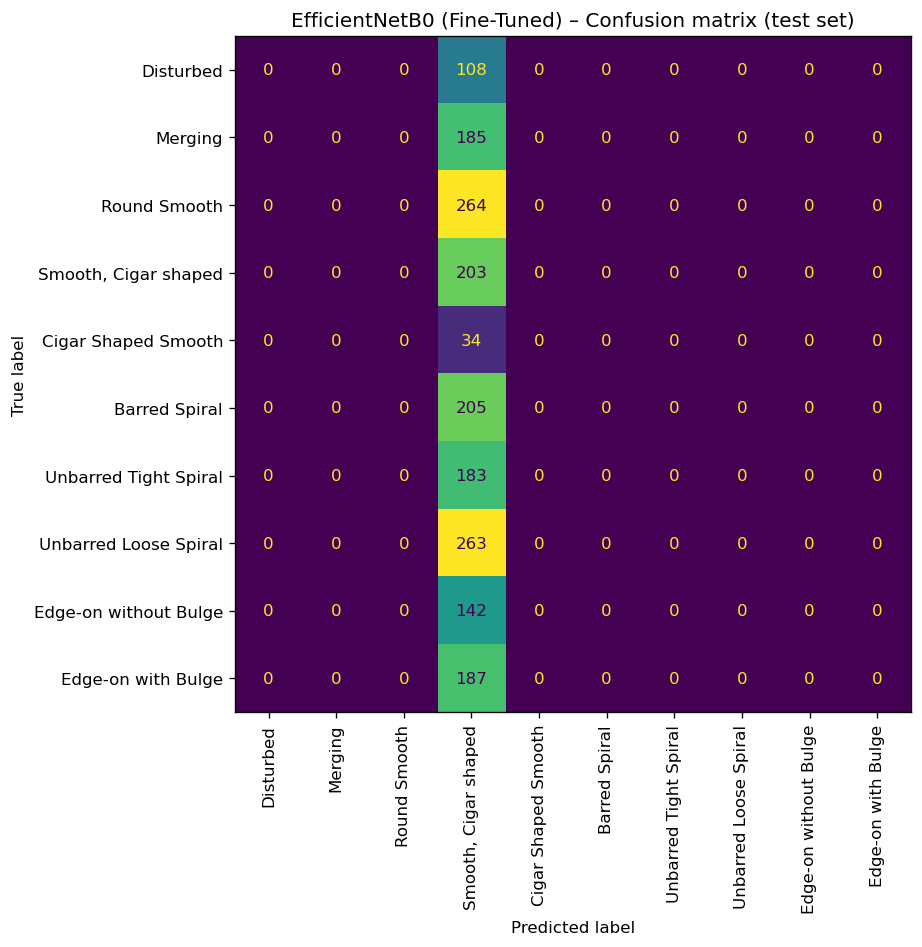

In [ ]:
results_summaries: list[dict] = []

results_summaries.append(
    evaluate_model(
        baseline_eval_model,
        X_test_base,
        y_test_int,
        model_name="Baseline CNN",
        class_names_local=class_names,
        filename_prefix="baseline_cnn",
    )
)

results_summaries.append(
    evaluate_model(
        frozen_eval_model,
        X_test,
        y_test_int,
        model_name="EfficientNetB0 (Frozen TL)",
        class_names_local=class_names,
        filename_prefix="efficientnetb0_frozen",
    )
)

results_summaries.append(
    evaluate_model(
        finetuned_eval_model,
        X_test,
        y_test_int,
        model_name="EfficientNetB0 (Fine-Tuned)",
        class_names_local=class_names,
        filename_prefix="efficientnetb0_finetuned",
    )
)


In [ ]:
results_df = pd.DataFrame(results_summaries)
print(results_df)
results_df.to_csv("model_comparison_metrics.csv", index=False)

                         model  accuracy  macro_f1  macro_recall
0                 Baseline CNN  0.529312  0.514105      0.536423
1   EfficientNetB0 (Frozen TL)  0.103157  0.018702      0.100000
2  EfficientNetB0 (Fine-Tuned)  0.114431  0.020536      0.100000


### Error analysis: show examples of misclassified galaxies

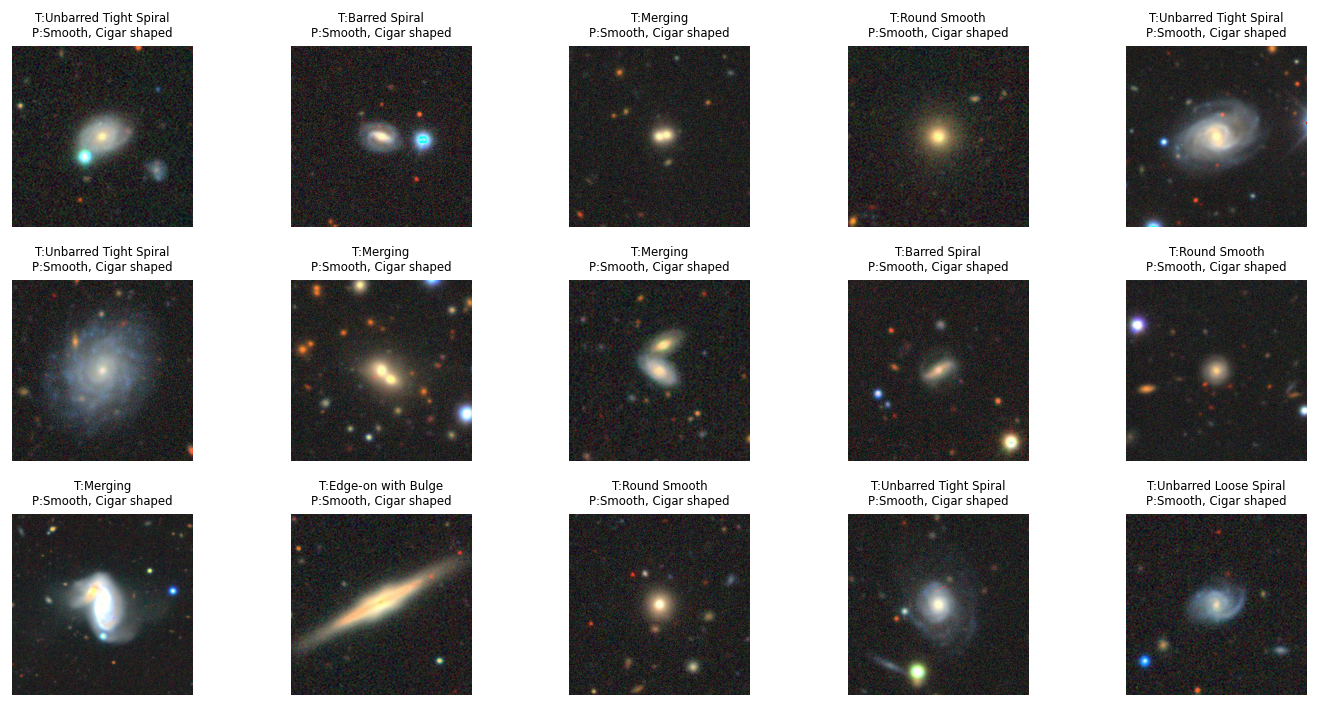

Saved training_histories.npz with keys: ['baseline', 'tl', 'ft']


In [ ]:

# ===== 8. Error analysis for fine-tuned model =====
y_prob_ft = finetuned_eval_model.predict(X_test, verbose=0)
y_pred_ft = np.argmax(y_prob_ft, axis=1)
y_true_ft = y_test_int

mis_idx = np.where(y_pred_ft != y_true_ft)[0]
np.random.shuffle(mis_idx)
mis_idx = mis_idx[:15]

plt.figure(figsize=(12, 6))
for i, idx in enumerate(mis_idx):
    ax = plt.subplot(3, 5, i + 1)
    ax.imshow(X_test[idx])
    true_lbl = galaxy10cls_lookup(int(y_true_ft[idx]))
    pred_lbl = galaxy10cls_lookup(int(y_pred_ft[idx]))
    ax.set_title(f"T:{true_lbl}\nP:{pred_lbl}", fontsize=7)
    ax.axis("off")
plt.tight_layout()
plt.savefig("misclassified_examples_finetuned.png", bbox_inches="tight")
plt.show()


# ===== 9. Save training histories =====
history_dict = {
    "baseline": history_baseline.history,
    "tl": history_tl.history,
    "ft": history_ft.history,
}
np.savez("training_histories.npz", **history_dict)
print("Saved training_histories.npz with keys:", list(history_dict.keys()))